In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [2]:
df = pd.read_csv(r"C:\Users\rpap9\OneDrive\Desktop\ML Project\heart failure.csv")

In [3]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [5]:
print("\nSummary Statistics (Numerical Columns):")
print(df.describe())

# Display summary statistics for categorical columns
print("\nSummary Statistics (Categorical Columns):")
print(df.describe(include='object'))


Summary Statistics (Numerical Columns):
              Age   RestingBP  Cholesterol   FastingBS       MaxHR  \
count  918.000000  918.000000   918.000000  918.000000  918.000000   
mean    53.510893  132.396514   198.799564    0.233115  136.809368   
std      9.432617   18.514154   109.384145    0.423046   25.460334   
min     28.000000    0.000000     0.000000    0.000000   60.000000   
25%     47.000000  120.000000   173.250000    0.000000  120.000000   
50%     54.000000  130.000000   223.000000    0.000000  138.000000   
75%     60.000000  140.000000   267.000000    0.000000  156.000000   
max     77.000000  200.000000   603.000000    1.000000  202.000000   

          Oldpeak  HeartDisease  
count  918.000000    918.000000  
mean     0.887364      0.553377  
std      1.066570      0.497414  
min     -2.600000      0.000000  
25%      0.000000      0.000000  
50%      0.600000      1.000000  
75%      1.500000      1.000000  
max      6.200000      1.000000  

Summary Statistics (C

C:\Users\rpap9\AppData\Local\Temp\ipykernel_9072\1062402965.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='HeartDisease', data=df, palette='viridis')


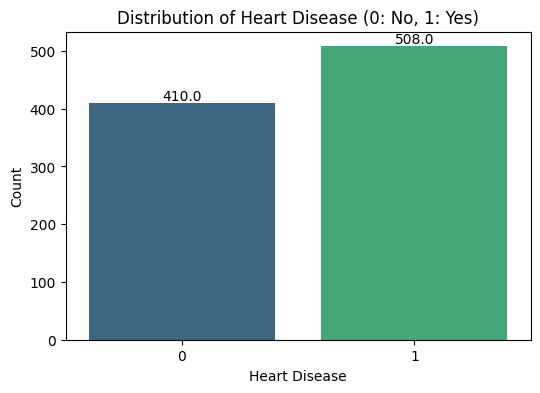


Target Variable (HeartDisease) Distribution:
HeartDisease
1    55.337691
0    44.662309
Name: proportion, dtype: float64


In [6]:
# 1. Target Variable Distribution (HeartDisease)
plt.figure(figsize=(6, 4))
sns.countplot(x='HeartDisease', data=df, palette='viridis')
plt.title('Distribution of Heart Disease (0: No, 1: Yes)')
plt.xlabel('Heart Disease')
plt.ylabel('Count')
# Add counts on top of bars
ax = plt.gca()
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                textcoords='offset points')
plt.show()
print("\nTarget Variable (HeartDisease) Distribution:")
print(df['HeartDisease'].value_counts(normalize=True) * 100)

In [7]:
# 2. Numerical Features Analysis
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
# Remove target variable if it's numerical (which it is here)
numerical_cols.remove('HeartDisease')
# FastingBS is technically numerical (0/1) but often treated as categorical. Let's keep it here for now.
print(f"\nNumerical columns: {numerical_cols}")


Numerical columns: ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']



Histograms for Numerical Features:


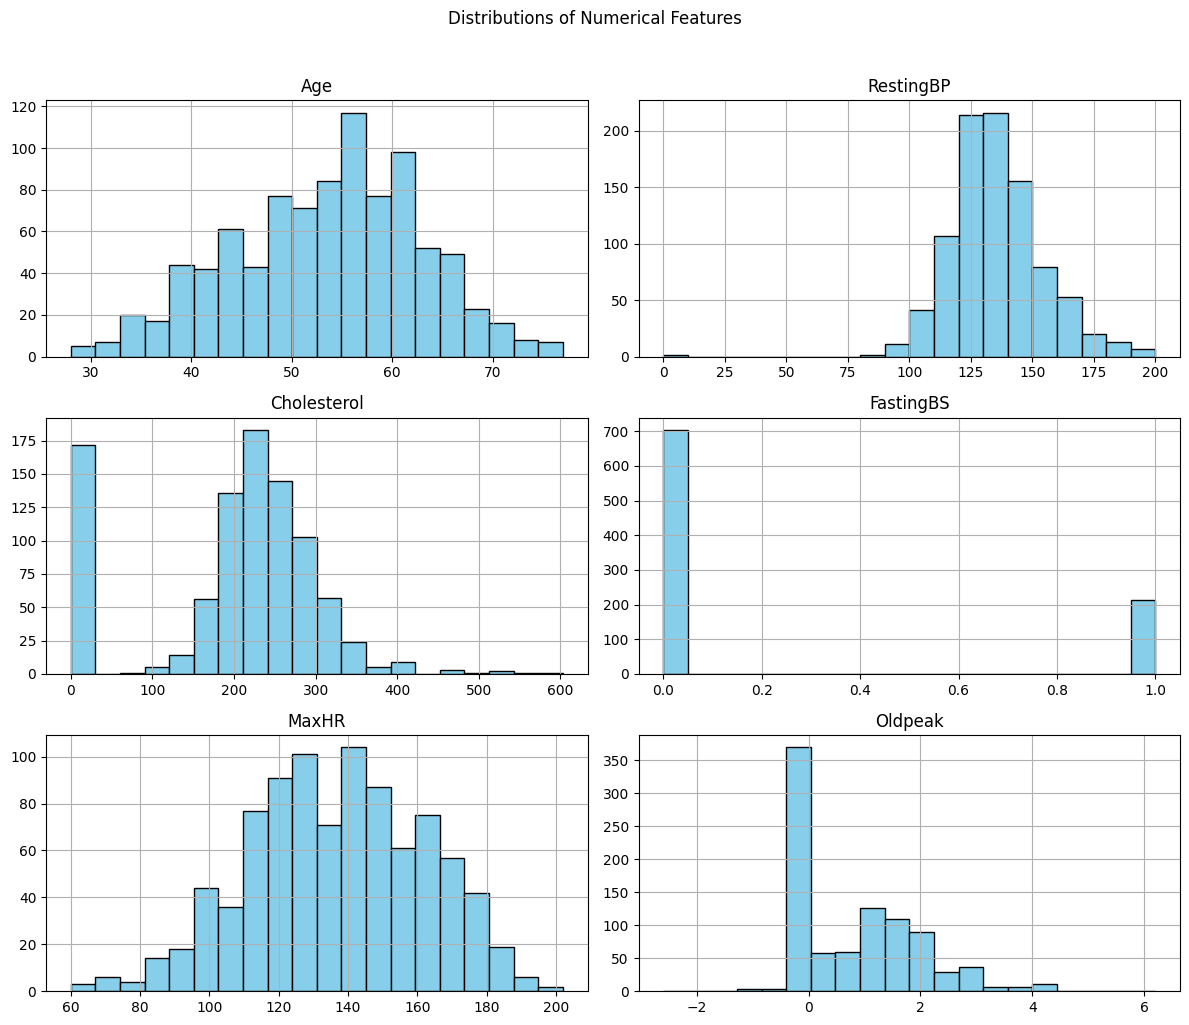

In [8]:
# Histograms for numerical features
print("\nHistograms for Numerical Features:")
df[numerical_cols].hist(figsize=(12, 10), bins=20, color='skyblue', edgecolor='black')
plt.suptitle('Distributions of Numerical Features', y=1.02)
plt.tight_layout()
plt.show()


Boxplots for Numerical Features vs. Heart Disease:


C:\Users\rpap9\AppData\Local\Temp\ipykernel_9072\1166329981.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='HeartDisease', y=col, data=df, palette='coolwarm')
C:\Users\rpap9\AppData\Local\Temp\ipykernel_9072\1166329981.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='HeartDisease', y=col, data=df, palette='coolwarm')
C:\Users\rpap9\AppData\Local\Temp\ipykernel_9072\1166329981.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='HeartDisease', y=col, data=df, palette='coolwarm')
C:\Users\rpap9\AppData\Local\Temp\ipykernel_9072\

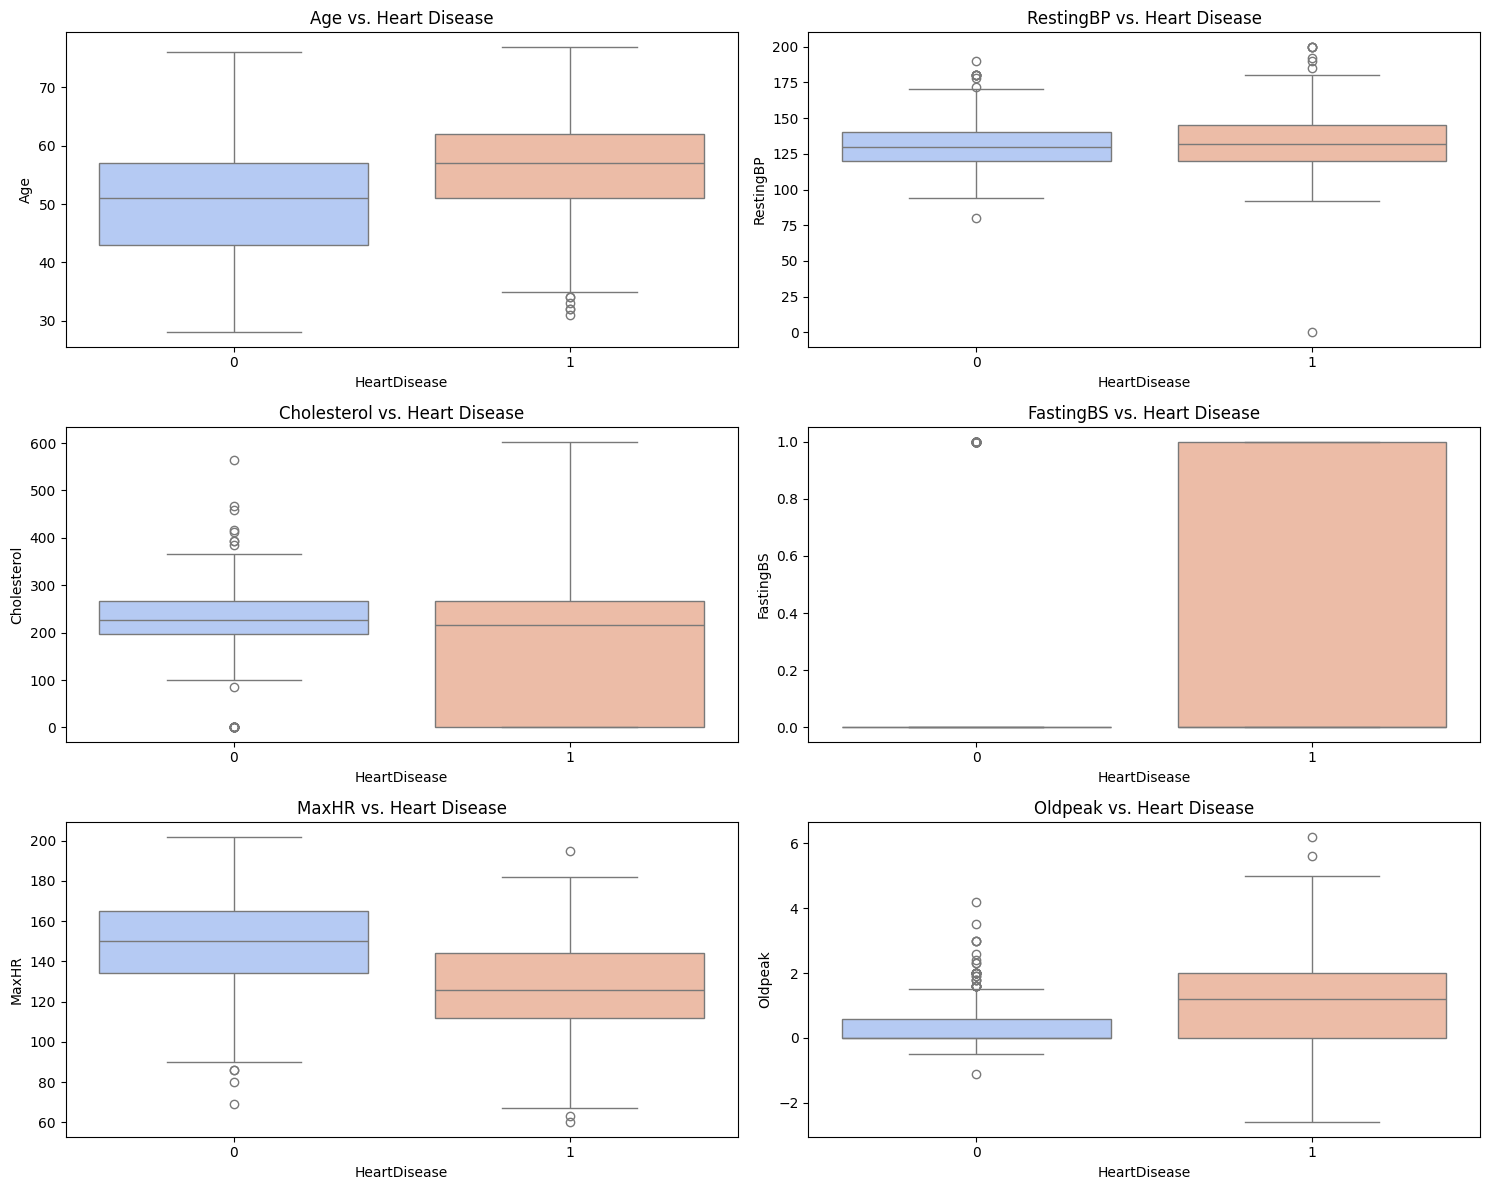

In [9]:
# Boxplots for numerical features vs. HeartDisease
print("\nBoxplots for Numerical Features vs. Heart Disease:")
plt.figure(figsize=(15, 12))
for i, col in enumerate(numerical_cols):
    plt.subplot((len(numerical_cols) + 1) // 2, 2, i + 1)
    sns.boxplot(x='HeartDisease', y=col, data=df, palette='coolwarm')
    plt.title(f'{col} vs. Heart Disease')
plt.tight_layout()
plt.show()

In [10]:
# 3. Categorical Features Analysis
categorical_cols = df.select_dtypes(include='object').columns.tolist()
# Include FastingBS here if treating as categorical
# Note: FastingBS is 0/1, let's treat it as numerical for simplicity in initial EDA plots
# but will handle it appropriately in preprocessing if needed.
# 'HeartDisease' is the target, 'FastingBS' is 0/1.

print(f"\nCategorical columns: {categorical_cols}")



Categorical columns: ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']



Countplots for Categorical Features:


C:\Users\rpap9\AppData\Local\Temp\ipykernel_9072\2806685100.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette='pastel', order=df[col].value_counts().index)
C:\Users\rpap9\AppData\Local\Temp\ipykernel_9072\2806685100.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette='pastel', order=df[col].value_counts().index)
C:\Users\rpap9\AppData\Local\Temp\ipykernel_9072\2806685100.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette='pastel', order=df[col].value_counts().in

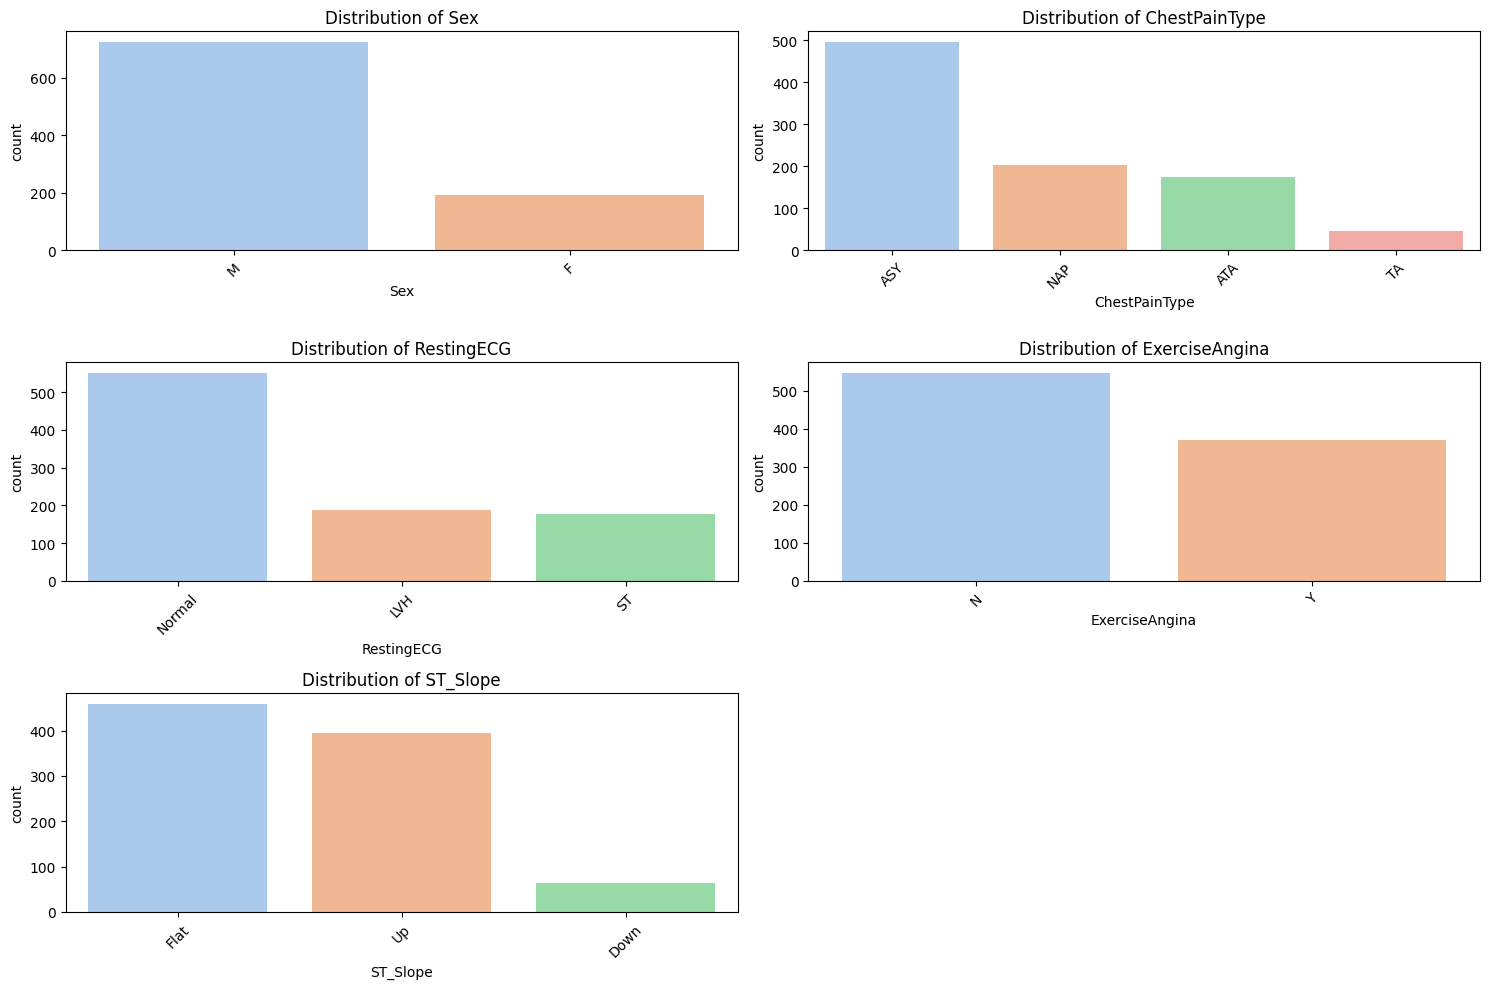

In [11]:
# Countplots for categorical features
print("\nCountplots for Categorical Features:")
plt.figure(figsize=(15, 10))
for i, col in enumerate(categorical_cols):
    plt.subplot((len(categorical_cols) + 1) // 2, 2, i + 1)
    sns.countplot(x=col, data=df, palette='pastel', order=df[col].value_counts().index)
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



Countplots for Categorical Features vs. Heart Disease:


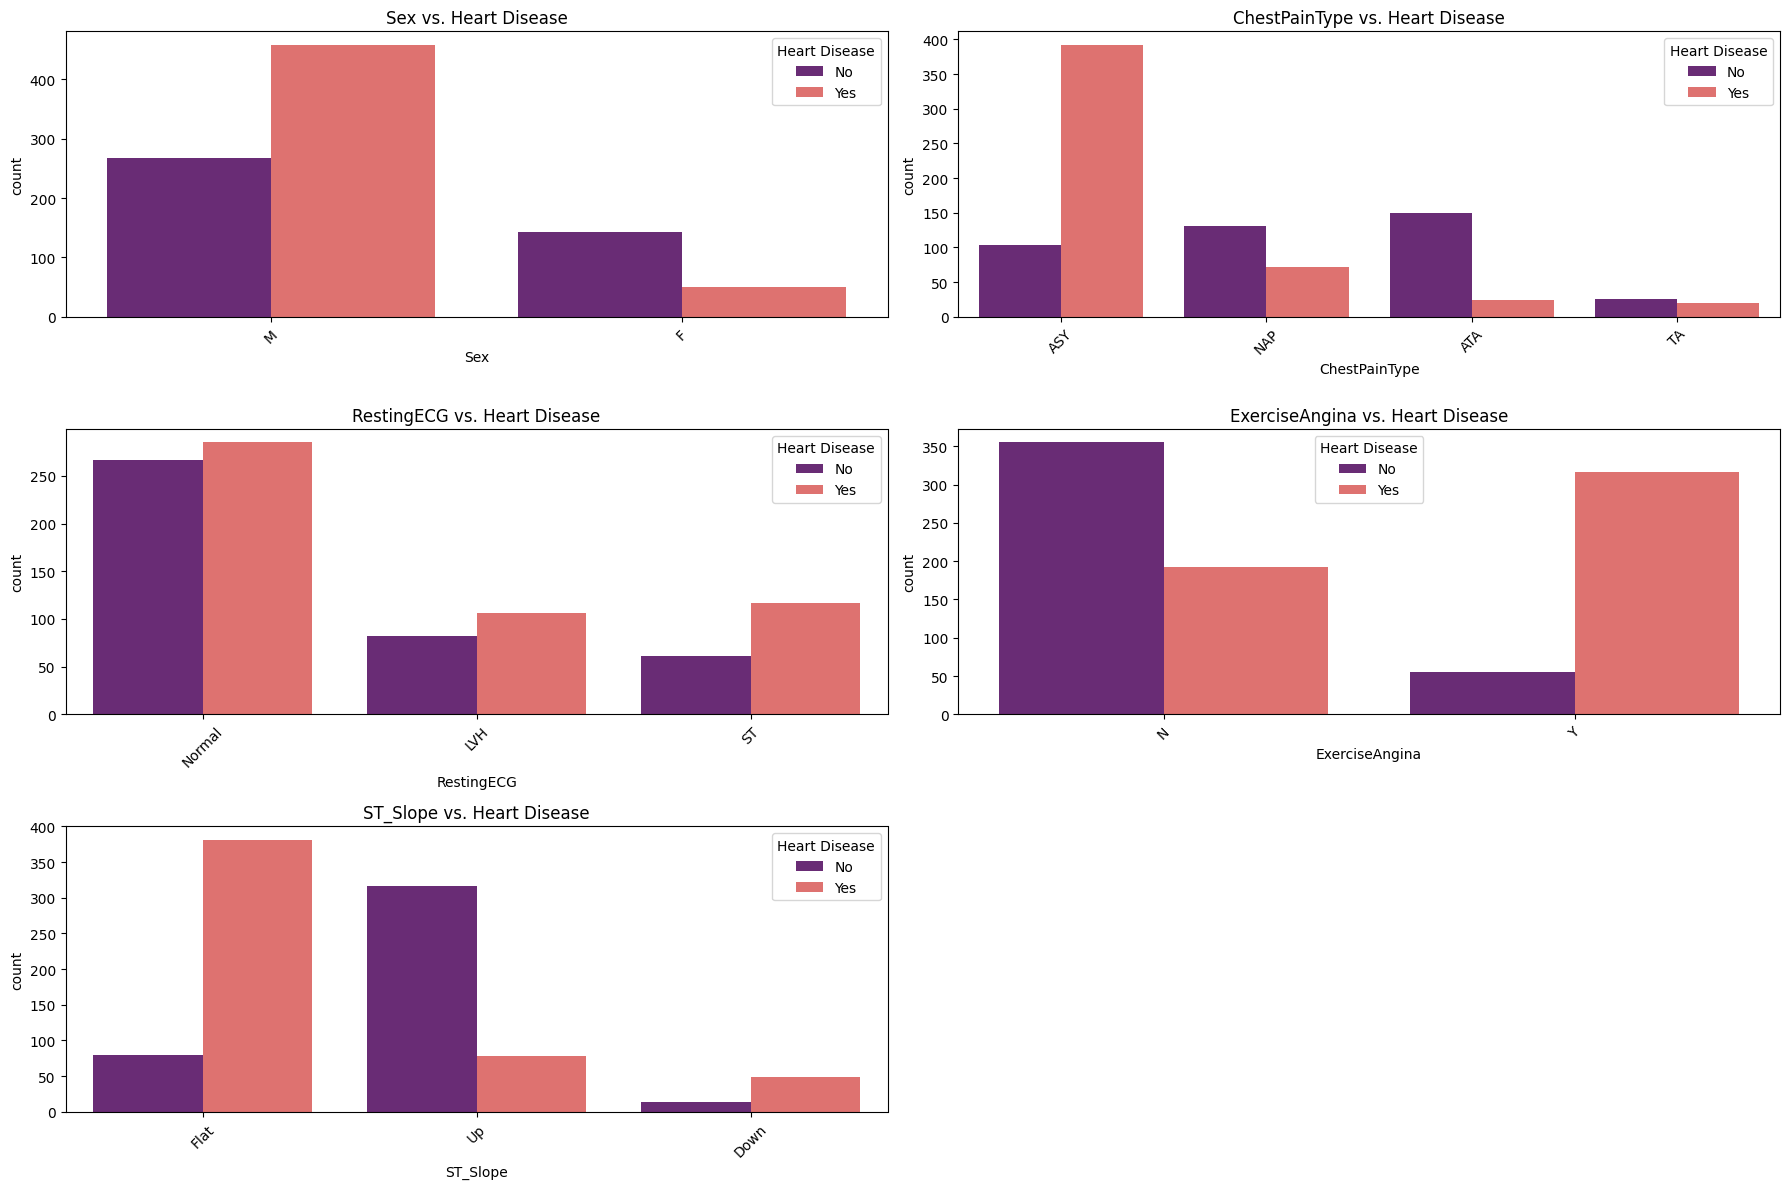

In [12]:
# Countplots for categorical features vs. HeartDisease
print("\nCountplots for Categorical Features vs. Heart Disease:")
plt.figure(figsize=(18, 12))
for i, col in enumerate(categorical_cols):
    plt.subplot((len(categorical_cols) + 1) // 2, 2, i + 1)
    sns.countplot(x=col, hue='HeartDisease', data=df, palette='magma', order=df[col].value_counts().index)
    plt.title(f'{col} vs. Heart Disease')
    plt.xticks(rotation=45)
    plt.legend(title='Heart Disease', labels=['No', 'Yes'])
plt.tight_layout()
plt.show()

In [13]:
# 4. Check for Missing Values (already did with info(), but summing helps)
print("\nMissing Values Check:")
print(df.isnull().sum())
# Note: Cholesterol and RestingBP have 0 values which might be unrealistic.
print("\nChecking for 0 values in potentially problematic columns:")
print(f"Number of 0 values in Cholesterol: {(df['Cholesterol'] == 0).sum()}")
print(f"Number of 0 values in RestingBP: {(df['RestingBP'] == 0).sum()}")
# We will handle these 0 values in the preprocessing step.


Missing Values Check:
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

Checking for 0 values in potentially problematic columns:
Number of 0 values in Cholesterol: 172
Number of 0 values in RestingBP: 1


In [14]:
# Create a copy to avoid modifying the original DataFrame
df_processed = df.copy()

# 1. Handle unrealistic 0 values in 'Cholesterol' and 'RestingBP'
# Replace 0 with the median of the non-zero values in each column
chol_median = df_processed[df_processed['Cholesterol'] != 0]['Cholesterol'].median()
bp_median = df_processed[df_processed['RestingBP'] != 0]['RestingBP'].median()

print(f"\nReplacing 0s in Cholesterol with median: {chol_median}")
df_processed['Cholesterol'] = df_processed['Cholesterol'].replace(0, chol_median)
print(f"Number of 0 values in Cholesterol after replacement: {(df_processed['Cholesterol'] == 0).sum()}")

print(f"\nReplacing 0s in RestingBP with median: {bp_median}")
df_processed['RestingBP'] = df_processed['RestingBP'].replace(0, bp_median)
print(f"Number of 0 values in RestingBP after replacement: {(df_processed['RestingBP'] == 0).sum()}")

print("\nDataset sample after handling 0s:")
print(df_processed.head())



Replacing 0s in Cholesterol with median: 237.0
Number of 0 values in Cholesterol after replacement: 0

Replacing 0s in RestingBP with median: 130.0
Number of 0 values in RestingBP after replacement: 0

Dataset sample after handling 0s:
   Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR  \
0   40   M           ATA        140          289          0     Normal    172   
1   49   F           NAP        160          180          0     Normal    156   
2   37   M           ATA        130          283          0         ST     98   
3   48   F           ASY        138          214          0     Normal    108   
4   54   M           NAP        150          195          0     Normal    122   

  ExerciseAngina  Oldpeak ST_Slope  HeartDisease  
0              N      0.0       Up             0  
1              N      1.0     Flat             1  
2              N      0.0       Up             0  
3              Y      1.5     Flat             1  
4              N     

In [15]:
# 2. Identify Feature Types for Encoding/Scaling
target = 'HeartDisease'
features = df_processed.drop(target, axis=1).columns

# Re-identify numerical and categorical features after handling 0s
numerical_features = df_processed[features].select_dtypes(include=np.number).columns.tolist()
categorical_features = df_processed[features].select_dtypes(include='object').columns.tolist()

print(f"\nNumerical Features identified: {numerical_features}")
print(f"Categorical Features identified: {categorical_features}")


Numerical Features identified: ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']
Categorical Features identified: ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']


In [16]:
# 3. Separate Features (X) and Target (y)
X = df_processed.drop(target, axis=1)
y = df_processed[target]

print(f"\nShape of features (X): {X.shape}")
print(f"Shape of target (y): {y.shape}")


Shape of features (X): (918, 11)
Shape of target (y): (918,)


In [17]:
# 4. Split Data into Training and Testing sets
# Use stratify=y because the target distribution is somewhat imbalanced
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nData split into training and testing sets:")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")
print("\nDistribution of target in training set:")
print(y_train.value_counts(normalize=True))
print("\nDistribution of target in testing set:")
print(y_test.value_counts(normalize=True))


Data split into training and testing sets:
X_train shape: (734, 11)
X_test shape: (184, 11)
y_train shape: (734,)
y_test shape: (184,)

Distribution of target in training set:
HeartDisease
1    0.553134
0    0.446866
Name: proportion, dtype: float64

Distribution of target in testing set:
HeartDisease
1    0.554348
0    0.445652
Name: proportion, dtype: float64


In [18]:
# 5. Preprocessing Pipeline (Encoding and Scaling)
# Create transformers for numerical and categorical features
# Numerical features need scaling
# Categorical features need one-hot encoding

# Define the transformers
numeric_transformer = StandardScaler()
categoric_transformer = OneHotEncoder(handle_unknown='ignore', drop='first') # drop='first' to avoid multicollinearity

# Create a preprocessor object using ColumnTransformer
# This applies the correct transformation to each column type
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features),
        ('cat', categoric_transformer, categorical_features)
    ],
    remainder='passthrough' # Keep other columns (if any) - though we shouldn't have any
)

# Apply the preprocessing steps: Fit on training data, transform both train and test
# Fit the preprocessor on the training data and transform it
print("\nFitting preprocessor and transforming training data...")
X_train_processed = preprocessor.fit_transform(X_train)
print("Training data transformed.")

# Transform the test data using the *fitted* preprocessor
print("\nTransforming test data...")
X_test_processed = preprocessor.transform(X_test)
print("Test data transformed.")


# Get feature names after encoding (useful for interpretation if needed)
# Need to be careful with drop='first' in OneHotEncoder
try:
    feature_names_out = preprocessor.get_feature_names_out()
    print("\nFeature names after processing:")
    # print(feature_names_out) # This can be a long list
    print(f"Number of features after processing: {len(feature_names_out)}")
except AttributeError:
    print("\nNote: get_feature_names_out requires scikit-learn >= 0.24. Using manual construction if needed.")

# Display shape and sample of processed data (it's a numpy array now)
print(f"\nShape of processed training data: {X_train_processed.shape}")
print(f"Shape of processed test data: {X_test_processed.shape}")
print("\nSample of processed training data (first 5 rows):")
# Convert to DataFrame for better viewing if desired, using feature_names_out
# X_train_processed_df = pd.DataFrame(X_train_processed, columns=feature_names_out)
# print(X_train_processed_df.head())
print(X_train_processed[:5, :])


Fitting preprocessor and transforming training data...
Training data transformed.

Transforming test data...
Test data transformed.

Feature names after processing:
Number of features after processing: 15

Shape of processed training data: (734, 15)
Shape of processed test data: (184, 15)

Sample of processed training data (first 5 rows):
[[ 0.9700116   0.3390158  -0.51402763  1.83549656 -0.32451998  0.31704567
   1.          1.          0.          0.          0.          1.
   1.          1.          0.        ]
 [ 0.12202766 -1.26603098 -0.56933885  1.83549656  1.68983661 -0.44035554
   1.          1.          0.          0.          0.          1.
   0.          0.          1.        ]
 [ 0.54601963 -0.15910217  1.71685831  1.83549656 -0.24704473  0.60107112
   0.          0.          0.          0.          0.          1.
   1.          1.          0.        ]
 [-0.72595627  1.50129106 -0.14528615 -0.5448117  -0.47947049 -0.81905614
   1.          0.          0.          0.      

In [19]:
print("\n--- Training Initial KNN Model (K=5) ---")

# Instantiate the KNN classifier
initial_k = 5
knn_initial = KNeighborsClassifier(n_neighbors=initial_k)
print(f"KNN classifier instantiated with n_neighbors = {initial_k}")

# Train the model on the processed training data
print("Training the initial KNN model...")
knn_initial.fit(X_train_processed, y_train)
print("Initial KNN model trained successfully.")

# Make predictions on the processed test data
print("\nMaking predictions on the test set...")
y_pred_initial = knn_initial.predict(X_test_processed)
print("Predictions made.")


--- Training Initial KNN Model (K=5) ---
KNN classifier instantiated with n_neighbors = 5
Training the initial KNN model...
Initial KNN model trained successfully.

Making predictions on the test set...
Predictions made.



--- Evaluating Initial KNN Model (K=5) ---
Initial KNN Model Accuracy (K=5): 0.8478

Confusion Matrix (K=5):


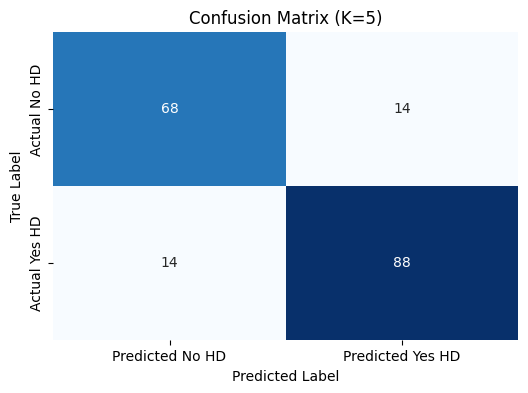


Classification Report (K=5):
                  precision    recall  f1-score   support

No Heart Disease       0.83      0.83      0.83        82
   Heart Disease       0.86      0.86      0.86       102

        accuracy                           0.85       184
       macro avg       0.85      0.85      0.85       184
    weighted avg       0.85      0.85      0.85       184


--- Initial Evaluation Completed ---

Goal Not Yet Achieved. Initial accuracy (0.8478) is below 90%. Proceeding to tuning.


In [20]:
print("\n--- Evaluating Initial KNN Model (K=5) ---")

# Calculate accuracy
accuracy_initial = accuracy_score(y_test, y_pred_initial)
print(f"Initial KNN Model Accuracy (K=5): {accuracy_initial:.4f}")

# Generate confusion matrix
print("\nConfusion Matrix (K=5):")
cm_initial = confusion_matrix(y_test, y_pred_initial)
# Plot confusion matrix for better visualization
plt.figure(figsize=(6, 4))
sns.heatmap(cm_initial, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted No HD', 'Predicted Yes HD'],
            yticklabels=['Actual No HD', 'Actual Yes HD'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title(f'Confusion Matrix (K={initial_k})')
plt.show()

# Generate classification report
print("\nClassification Report (K=5):")
cr_initial = classification_report(y_test, y_pred_initial, target_names=['No Heart Disease', 'Heart Disease'])
print(cr_initial)

print("\n--- Initial Evaluation Completed ---")
# Check if initial accuracy meets the >90% goal. It might not yet.
if accuracy_initial > 0.90:
    print(f"\nGoal Achieved! Initial accuracy ({accuracy_initial:.4f}) is already above 90%.")
else:
    print(f"\nGoal Not Yet Achieved. Initial accuracy ({accuracy_initial:.4f}) is below 90%. Proceeding to tuning.")


--- Hyperparameter Tuning (Finding Best K using GridSearchCV) ---
Parameter grid for K: {'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30]}
GridSearchCV instantiated. Starting the search...
GridSearchCV fitting completed.

Best K found: 10
Best cross-validation accuracy score: 0.8515


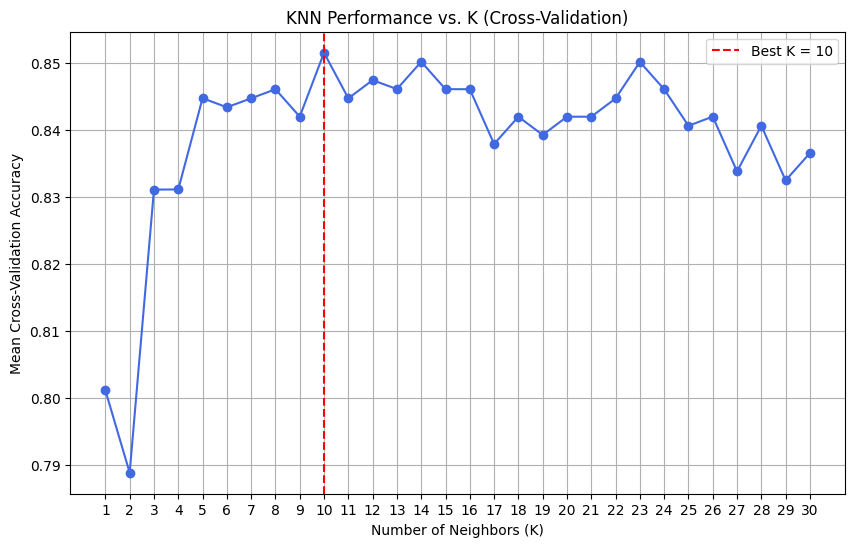


--- Hyperparameter Tuning Completed ---


In [21]:
print("\n--- Hyperparameter Tuning (Finding Best K using GridSearchCV) ---")

# Define the parameter grid for K
# Let's test K values from 1 to 30 
k_range = list(range(1, 31))
param_grid = {'n_neighbors': k_range}
print(f"Parameter grid for K: {param_grid}")

# Instantiate the KNN classifier (without specifying K yet)
knn_tune = KNeighborsClassifier()

grid_search = GridSearchCV(knn_tune, param_grid, cv=5, scoring='accuracy', n_jobs=-1) # n_jobs=-1 uses all available CPU cores
print("GridSearchCV instantiated. Starting the search...")

# Fit GridSearchCV on the processed *training* data
grid_search.fit(X_train_processed, y_train)

print("GridSearchCV fitting completed.")

# Get the best K and the best score
best_k = grid_search.best_params_['n_neighbors']
best_score = grid_search.best_score_

print(f"\nBest K found: {best_k}")
print(f"Best cross-validation accuracy score: {best_score:.4f}")

# Optional: Plot K vs. Cross-Validation Accuracy
cv_results = grid_search.cv_results_
mean_test_scores = cv_results['mean_test_score']

plt.figure(figsize=(10, 6))
plt.plot(k_range, mean_test_scores, marker='o', linestyle='-', color='royalblue')
plt.title('KNN Performance vs. K (Cross-Validation)')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Mean Cross-Validation Accuracy')
plt.xticks(k_range)
plt.grid(True)
plt.axvline(best_k, color='red', linestyle='--', label=f'Best K = {best_k}')
plt.legend()
plt.show()

print("\n--- Hyperparameter Tuning Completed ---")

In [22]:
print("\n--- Training Final KNN Model (Best K) ---")

# Instantiate the final KNN classifier with the best K
knn_final = KNeighborsClassifier(n_neighbors=best_k)
print(f"Final KNN classifier instantiated with best K = {best_k}")

# Train the final model on the entire processed training data
print("Training the final KNN model...")
knn_final.fit(X_train_processed, y_train)
print("Final KNN model trained successfully.")


--- Training Final KNN Model (Best K) ---
Final KNN classifier instantiated with best K = 10
Training the final KNN model...
Final KNN model trained successfully.



--- Evaluating Final KNN Model (Best K) ---
Making predictions with the final model...
Predictions made.

Final KNN Model Accuracy (K=10): 0.8696

Final Confusion Matrix (K={best_k}):


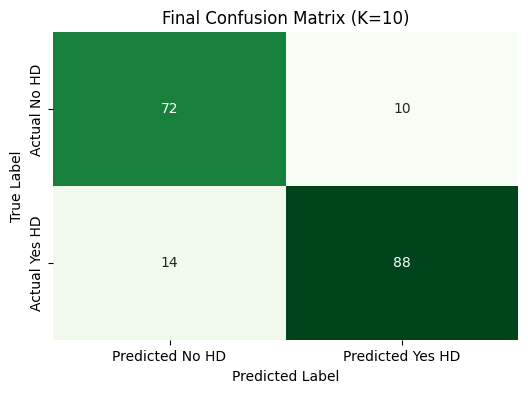


Final Classification Report (K={best_k}):
                  precision    recall  f1-score   support

No Heart Disease       0.84      0.88      0.86        82
   Heart Disease       0.90      0.86      0.88       102

        accuracy                           0.87       184
       macro avg       0.87      0.87      0.87       184
    weighted avg       0.87      0.87      0.87       184


--- Final Evaluation Completed ---

Goal Not Quite Achieved (Below 90%). However, tuning improved accuracy from 0.8478 to 0.8696.

--- KNN Analysis Finished ---


In [23]:
print("\n--- Evaluating Final KNN Model (Best K) ---")

# Make predictions on the processed test data using the final model
print("Making predictions with the final model...")
y_pred_final = knn_final.predict(X_test_processed)
print("Predictions made.")

# Calculate final accuracy
accuracy_final = accuracy_score(y_test, y_pred_final)
print(f"\nFinal KNN Model Accuracy (K={best_k}): {accuracy_final:.4f}")

# Generate final confusion matrix
print("\nFinal Confusion Matrix (K={best_k}):")
cm_final = confusion_matrix(y_test, y_pred_final)
# Plot confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['Predicted No HD', 'Predicted Yes HD'],
            yticklabels=['Actual No HD', 'Actual Yes HD'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title(f'Final Confusion Matrix (K={best_k})')
plt.show()

# Generate final classification report
print("\nFinal Classification Report (K={best_k}):")
cr_final = classification_report(y_test, y_pred_final, target_names=['No Heart Disease', 'Heart Disease'])
print(cr_final)

print("\n--- Final Evaluation Completed ---")

# Final check on the goal
if accuracy_final > 0.90:
    print(f"\nGoal Achieved! Final accuracy ({accuracy_final:.4f}) is above 90%.")
elif accuracy_final > accuracy_initial:
     print(f"\nGoal Not Quite Achieved (Below 90%). However, tuning improved accuracy from {accuracy_initial:.4f} to {accuracy_final:.4f}.")
else:
    print(f"\nGoal Not Achieved. Final accuracy ({accuracy_final:.4f}) is below 90%, and tuning did not significantly improve performance over K=5.")

print("\n--- KNN Analysis Finished ---")